# CIFAR10 Classification using ResNet


## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 2. Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 3. Data Augmentation & Preprocessing

In [3]:
# Train: with augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Test: no augmentation
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

## 4. Load CIFAR10 Dataset

In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 35.7MB/s]


Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 5. ResNet Model

In [5]:
# ===========================
# Residual Block
# ===========================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out  = torch.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # skip connection
        out  = torch.relu(out)
        return out


# ===========================
# Simple ResNet
# ===========================
class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1   = nn.BatchNorm2d(64)

        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

## 6. Initialize Model, Loss & Optimizer

In [7]:
model = SimpleResNet().to(device)

criterion = nn.CrossEntropyLoss()
epochs = 15

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


print("Total parameters:", sum(p.numel() for p in model.parameters()))

Total parameters: 2779914


## 7. Training Loop

In [8]:
train_losses     = []
test_losses      = []
train_accuracies = []
test_accuracies  = []

epochs = 15

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    running_loss = 0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ===== TEST =====
    model.eval()
    correct   = 0
    total     = 0
    test_loss = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs  = model(images)
            loss     = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total       += labels.size(0)
            correct     += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc  = 100 * correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.2f}%")
    print(f"  Test  Loss: {test_loss:.4f}  |  Test  Acc: {test_acc:.2f}%")
    scheduler.step()

Epoch [1/15]
  Train Loss: 1.6664  |  Train Acc: 38.31%
  Test  Loss: 1.4211  |  Test  Acc: 49.56%
Epoch [2/15]
  Train Loss: 1.1512  |  Train Acc: 58.12%
  Test  Loss: 1.3612  |  Test  Acc: 53.87%
Epoch [3/15]
  Train Loss: 0.8883  |  Train Acc: 68.49%
  Test  Loss: 1.0084  |  Test  Acc: 65.61%
Epoch [4/15]
  Train Loss: 0.7050  |  Train Acc: 75.26%
  Test  Loss: 1.1603  |  Test  Acc: 64.39%
Epoch [5/15]
  Train Loss: 0.5920  |  Train Acc: 79.49%
  Test  Loss: 0.6794  |  Test  Acc: 77.02%
Epoch [6/15]
  Train Loss: 0.5219  |  Train Acc: 82.04%
  Test  Loss: 0.6514  |  Test  Acc: 77.28%
Epoch [7/15]
  Train Loss: 0.4595  |  Train Acc: 84.11%
  Test  Loss: 0.5087  |  Test  Acc: 82.26%
Epoch [8/15]
  Train Loss: 0.4112  |  Train Acc: 85.80%
  Test  Loss: 0.5480  |  Test  Acc: 81.80%
Epoch [9/15]
  Train Loss: 0.3601  |  Train Acc: 87.60%
  Test  Loss: 0.4646  |  Test  Acc: 84.22%
Epoch [10/15]
  Train Loss: 0.3101  |  Train Acc: 89.28%
  Test  Loss: 0.4195  |  Test  Acc: 85.75%
Epoch [11

In [11]:
torch.save(model.state_dict(), 'resnet_cifar10.pth')

## 8. Final Test Accuracy

In [ ]:
print(f"\nFinal Test Accuracy: {test_accuracies[-1]:.2f}%")


Final Test Accuracy: 88.09%


## 9. Plot Loss & Accuracy

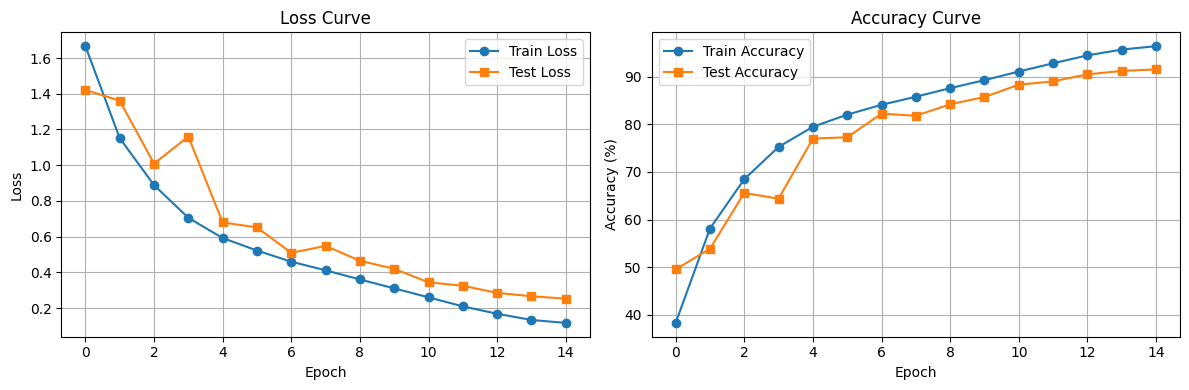

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(test_losses,  label='Test Loss',  marker='s')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accuracies, label='Train Accuracy', marker='o')
axes[1].plot(test_accuracies,  label='Test Accuracy',  marker='s')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

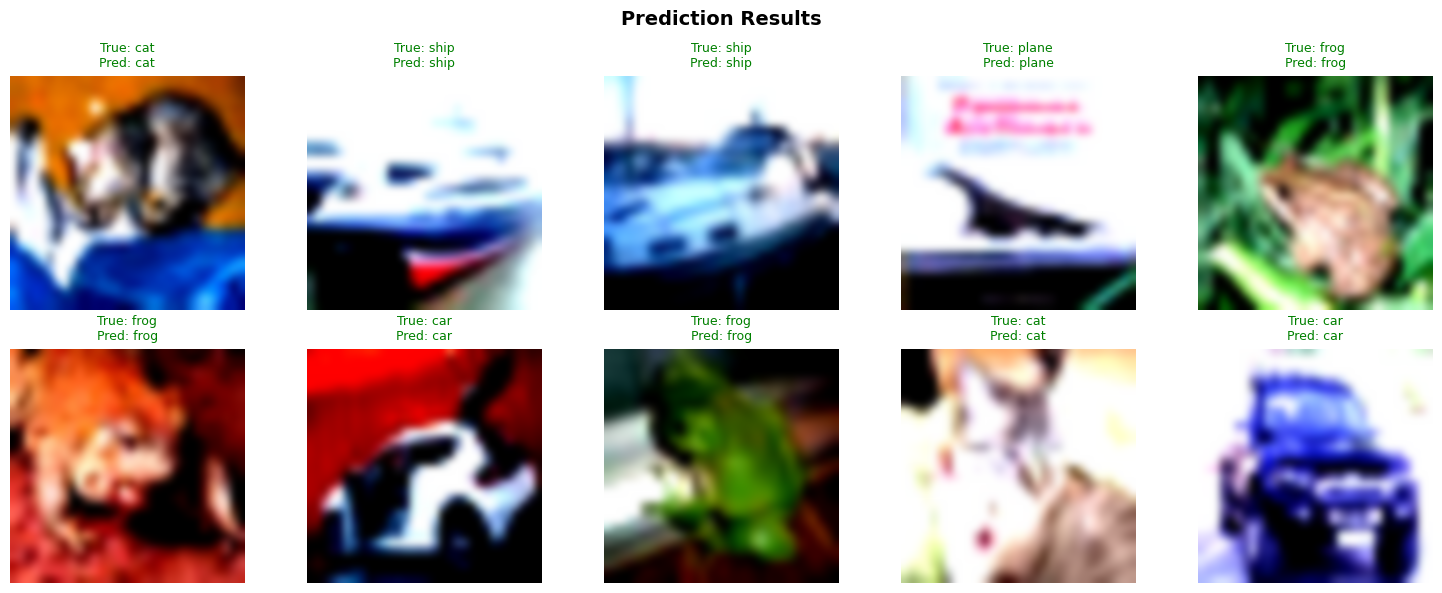

In [10]:
# ===== Prediction Visualization =====
model.eval()
images_shown = 0
fig = plt.figure(figsize=(15, 6))

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(images)):
            if images_shown >= 10:
                break

            ax = fig.add_subplot(2, 5, images_shown + 1)

            img = images[i].cpu().numpy().transpose(1, 2, 0)
            img = img * 0.5 + 0.5
            img = img.clip(0, 1)

            ax.imshow(img, interpolation='bicubic')

            true_label = classes[labels[i]]
            pred_label = classes[predicted[i]]

            color = "green" if true_label == pred_label else "red"
            ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                         fontsize=9, color=color)
            ax.axis('off')
            images_shown += 1

        if images_shown >= 10:
            break

plt.suptitle("Prediction Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()